# Temporal Generalization Analysis

A key question in fraud detection: does a model trained on past fraud 
generalize to future, unseen fraud patterns?

We evaluate the GCN timestep by timestep on the test set (35-49), 
measuring how performance degrades as we move further from the training data.
This mirrors real-world conditions where fraud methods evolve over time.

In [1]:
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch_geometric.datasets import EllipticBitcoinDataset
from sklearn.metrics import roc_auc_score, f1_score
import sys
sys.path.append('..')
from src.models import GCN

# Load data
dataset = EllipticBitcoinDataset(root='../data/elliptic')
data = dataset[0]

feat_df = pd.read_csv('../data/elliptic/raw/elliptic_txs_features.csv', header=None)
class_df = pd.read_csv('../data/elliptic/raw/elliptic_txs_classes.csv')
feat_df.columns = ['txId'] + [f'f{i}' for i in range(1, feat_df.shape[1])]
feat_df['timestep'] = feat_df['f1'].astype(int)
class_df.columns = ['txId', 'label']
df_meta = feat_df[['txId', 'timestep']].merge(class_df, on='txId')
timesteps = torch.tensor(df_meta['timestep'].values)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data = data.to(device)
timesteps = timesteps.to(device)

print(f"Device: {device}")
print("Data loaded")

Device: cuda
Data loaded


## 1. Train the GCN
Same setup as notebook 03: trained on timesteps 1-34.

In [2]:
# Setup
labeled_mask = data.y != 0
train_mask = labeled_mask & (timesteps <= 34)

y_binary = torch.zeros(data.y.shape, dtype=torch.long).to(device)
y_binary[data.y == 1] = 1
y_binary[data.y == 2] = 0

n_licit = (y_binary[train_mask] == 0).sum().item()
n_illicit = (y_binary[train_mask] == 1).sum().item()
weight = torch.tensor([1.0, n_licit / n_illicit]).to(device)

model = GCN(in_channels=165, hidden_channels=64, out_channels=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss(weight=weight)

# Train
for epoch in range(1, 201):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[train_mask], y_binary[train_mask])
    loss.backward()
    optimizer.step()

print("Training complete")

# Save model
torch.save(model.state_dict(), '../data/gcn_weights.pt')
print("Model saved")

Training complete
Model saved


## 2. Timestep-by-Timestep Evaluation

We evaluate the model separately on each test timestep (35-49).
If performance degrades over time, it means fraud patterns are evolving
faster than the model can generalize.

In [3]:
model.eval()
results = []

with torch.no_grad():
    out = model(data.x, data.edge_index)
    prob = F.softmax(out, dim=1)[:, 1]
    pred = out.argmax(dim=1)

for t in range(35, 50):
    t_mask = labeled_mask & (timesteps == t)
    if t_mask.sum() == 0:
        continue

    y_true = y_binary[t_mask].cpu().numpy()
    y_prob = prob[t_mask].cpu().numpy()
    y_pred = pred[t_mask].cpu().numpy()

    if y_true.sum() == 0:
        continue

    auc = roc_auc_score(y_true, y_prob)
    recall = (y_pred[y_true == 1] == 1).sum() / (y_true == 1).sum()
    precision = (y_true[y_pred == 1] == 1).sum() / max((y_pred == 1).sum(), 1)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    n_illicit = y_true.sum()

    results.append({
        'timestep': t,
        'auc': auc,
        'recall': recall,
        'precision': precision,
        'f1': f1,
        'n_illicit': n_illicit
    })
    print(f"t={t:2d} | AUC: {auc:.3f} | Recall: {recall:.2f} | Precision: {precision:.2f} | Illicit nodes: {n_illicit}")

df_results = pd.DataFrame(results)

t=35 | AUC: 0.845 | Recall: 0.55 | Precision: 0.22 | Illicit nodes: 182
t=36 | AUC: 0.731 | Recall: 0.30 | Precision: 0.04 | Illicit nodes: 33
t=37 | AUC: 0.899 | Recall: 0.60 | Precision: 0.18 | Illicit nodes: 40
t=38 | AUC: 0.793 | Recall: 0.42 | Precision: 0.31 | Illicit nodes: 111
t=39 | AUC: 0.755 | Recall: 0.14 | Precision: 0.13 | Illicit nodes: 81
t=40 | AUC: 0.676 | Recall: 0.22 | Precision: 0.20 | Illicit nodes: 112
t=41 | AUC: 0.736 | Recall: 0.16 | Precision: 0.11 | Illicit nodes: 116
t=42 | AUC: 0.798 | Recall: 0.15 | Precision: 0.27 | Illicit nodes: 239
t=43 | AUC: 0.719 | Recall: 0.00 | Precision: 0.00 | Illicit nodes: 24
t=44 | AUC: 0.543 | Recall: 0.04 | Precision: 0.01 | Illicit nodes: 24
t=45 | AUC: 0.621 | Recall: 0.20 | Precision: 0.03 | Illicit nodes: 5
t=46 | AUC: 0.554 | Recall: 0.00 | Precision: 0.00 | Illicit nodes: 2
t=47 | AUC: 0.805 | Recall: 0.14 | Precision: 0.18 | Illicit nodes: 22
t=48 | AUC: 0.922 | Recall: 0.19 | Precision: 0.22 | Illicit nodes: 36
t=4

## 3. Visualization

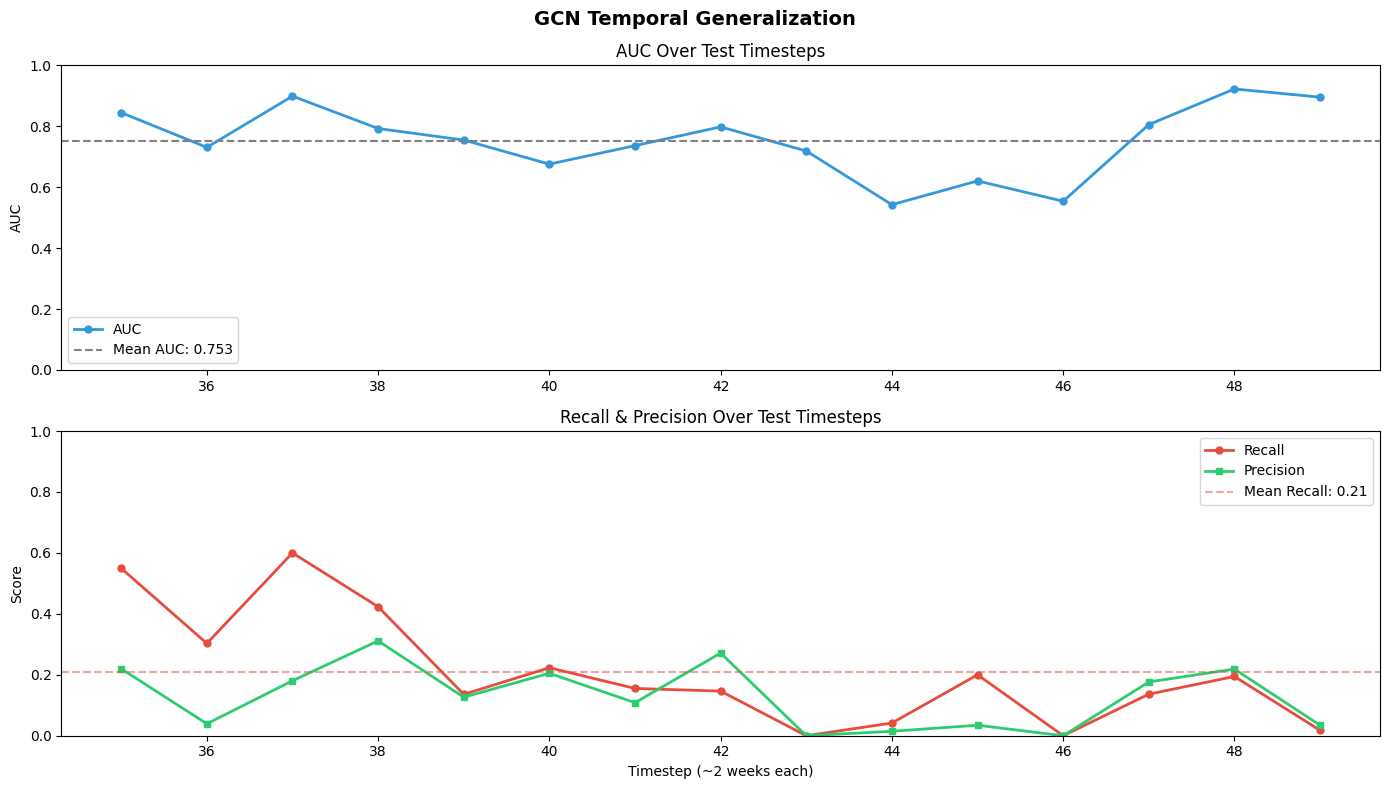

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(df_results['timestep'], df_results['auc'], 
             color='#3498db', linewidth=2, marker='o', markersize=5, label='AUC')
axes[0].axhline(y=df_results['auc'].mean(), color='gray', linestyle='--',
                label=f"Mean AUC: {df_results['auc'].mean():.3f}")
axes[0].set_title('AUC Over Test Timesteps')
axes[0].set_ylabel('AUC')
axes[0].legend()
axes[0].set_ylim(0, 1)

axes[1].plot(df_results['timestep'], df_results['recall'],
             color='#e74c3c', linewidth=2, marker='o', markersize=5, label='Recall')
axes[1].plot(df_results['timestep'], df_results['precision'],
             color='#2ecc71', linewidth=2, marker='s', markersize=5, label='Precision')
axes[1].axhline(y=df_results['recall'].mean(), color='#e74c3c', linestyle='--', alpha=0.5,
                label=f"Mean Recall: {df_results['recall'].mean():.2f}")
axes[1].set_title('Recall & Precision Over Test Timesteps')
axes[1].set_xlabel('Timestep (~2 weeks each)')
axes[1].set_ylabel('Score')
axes[1].legend()
axes[1].set_ylim(0, 1)

plt.suptitle('GCN Temporal Generalization', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/temporal_generalization.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Conclusions

Performance is not uniform across test timesteps:
- The model performs best on t=35-38, closest to the training period
- Recall drops sharply around t=43-46, suggesting new fraud patterns
  that the model has never seen during training
- AUC partially recovers in t=47-49, possibly due to fraud methods
  reverting to previously seen patterns

This confirms that static GNN models have a fundamental limitation
in fraud detection: fraud evolves, and models trained on past data
struggle to generalize to future attack patterns.

**The natural next step:** retrain the model incrementally as new 
timesteps become available, a technique known as continual learning.